
# <font color='blue'>Análise de Dados com Linguagem Python</font>




### Projeto de Análise de Dados Financeiros
Evolução do Preço das Ações da AstraZeneca

#### Definição do Problema

O objetivo deste projeto é analisar a evolução histórica do preço das ações da empresa AstraZeneca negociadas na bolsa de valores.

A análise busca responder perguntas como:

    Como o preço da ação evoluiu ao longo do tempo?
    Qual é a tendência de longo prazo?
    Qual é a volatilidade da ação?
    Como o volume de negociação se comporta?

Os dados serão obtidos diretamente da Yahoo Finance usando a biblioteca yfinance.

## Instalando e Carregando os Pacotes

In [1]:
# !pip install -q yfinance

import sys
!{sys.executable} -m pip install -q yfinance

In [2]:
# !pip install -q pandas_datareader

import sys
!{sys.executable} -m pip install pandas_datareader

In [3]:
# Imports
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pandas_datareader
import sqlite3
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8")

#### Coleta dos Dados

Aqui definimos o ticker da ação: AZN = ação da AstraZeneca.

In [4]:
# ticker da empresa
ticker = "AZN"

In [5]:
# download dos dados

AZN = yf.download(ticker, start="1993-01-01")

[*********************100%***********************]  1 of 1 completed


In [6]:
AZN.columns = AZN.columns.droplevel(1)

AZN = AZN.reset_index()

In [7]:
# visualização inicial

AZN.head()

Price,Date,Close,High,Low,Open,Volume
0,1993-05-12,3.352207,3.518432,3.338355,3.518432,207000
1,1993-05-13,3.227539,3.324503,3.185982,3.324503,396300
2,1993-05-14,3.185982,3.241391,3.185982,3.241391,323100
3,1993-05-17,3.255243,3.255243,3.213687,3.213687,34200
4,1993-05-18,3.227539,3.255243,3.213687,3.255243,34500


In [8]:
AZN.shape

(8282, 6)

In [9]:
AZN.head()

Price,Date,Close,High,Low,Open,Volume
0,1993-05-12,3.352207,3.518432,3.338355,3.518432,207000
1,1993-05-13,3.227539,3.324503,3.185982,3.324503,396300
2,1993-05-14,3.185982,3.241391,3.185982,3.241391,323100
3,1993-05-17,3.255243,3.255243,3.213687,3.213687,34200
4,1993-05-18,3.227539,3.255243,3.213687,3.255243,34500


In [10]:
AZN.describe()

Price,Date,Close,High,Low,Open,Volume
count,8282,8282.000000,8282.000000,8282.000000,8282.000000,8.282000e+03
mean,2009-10-18 06:56:25.269258496,45.260380,45.586416,44.920062,45.250246,1.590417e+06
min,1993-05-12 00:00:00,2.978202,2.992054,2.978202,2.978202,1.200000e+03
25%,2001-07-24 06:00:00,17.784939,17.962998,17.621532,17.746865,5.461750e+05
50%,2009-10-17 12:00:00,26.063034,26.185960,25.871116,26.057486,1.243375e+06
75%,2018-01-08 18:00:00,55.338870,55.680075,55.058500,55.373750,2.117988e+06
max,2026-04-07 00:00:00,208.619995,210.515323,206.949997,210.465836,3.277010e+07
std,NaN,42.888905,43.215265,42.568846,42.899057,1.714749e+06


In [11]:
AZN.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8282 entries, 0 to 8281
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    8282 non-null   datetime64[ns]
 1   Close   8282 non-null   float64       
 2   High    8282 non-null   float64       
 3   Low     8282 non-null   float64       
 4   Open    8282 non-null   float64       
 5   Volume  8282 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 388.3 KB


#### Armazenamento em Banco de Dados

Criando conexão com banco de dados. Aqui criamos um banco SQLite.

Arquivo criado: AZN.db

In [12]:
conn = sqlite3.connect("AZN.db")

AZN.to_sql("acoes_AZN", conn, if_exists="replace")

8282

#### Consulta SQL no banco

In [13]:
df_sql = pd.read_sql("SELECT * FROM acoes_AZN", conn)

df_sql.head()

,index,Date,Close,High,Low,Open,Volume
0,0,1993-05-12 00:00:00,3.352207,3.518432,3.338355,3.518432,207000
1,1,1993-05-13 00:00:00,3.227539,3.324503,3.185982,3.324503,396300
2,2,1993-05-14 00:00:00,3.185982,3.241391,3.185982,3.241391,323100
3,3,1993-05-17 00:00:00,3.255243,3.255243,3.213687,3.213687,34200
4,4,1993-05-18 00:00:00,3.227539,3.255243,3.213687,3.255243,34500


#### Salvando em Excel

In [15]:
# Salva em Excel - Exporta os dados para: AZN.xls - Isso permite abrir no Excel.

AZN.to_excel("AZN_dados.xlsx")

In [16]:
# Carregando os dados

df = pd.read_excel("AZN_dados.xlsx")

In [17]:
df.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume
0,0,1993-05-12,3.352207,3.518432,3.338355,3.518432,207000
1,1,1993-05-13,3.227539,3.324503,3.185982,3.324503,396300
2,2,1993-05-14,3.185982,3.241391,3.185982,3.241391,323100
3,3,1993-05-17,3.255243,3.255243,3.213687,3.213687,34200
4,4,1993-05-18,3.227539,3.255243,3.213687,3.255243,34500


In [18]:
# remover coluna extra criada pelo excel
df = df.drop(columns=["Unnamed: 0"])

df.head()

,Date,Close,High,Low,Open,Volume
0,1993-05-12,3.352207,3.518432,3.338355,3.518432,207000
1,1993-05-13,3.227539,3.324503,3.185982,3.324503,396300
2,1993-05-14,3.185982,3.241391,3.185982,3.241391,323100
3,1993-05-17,3.255243,3.255243,3.213687,3.213687,34200
4,1993-05-18,3.227539,3.255243,3.213687,3.255243,34500


#### Dataviz 12 - Gráfico de Linha com a evolução da variável preço ao longo do tempo

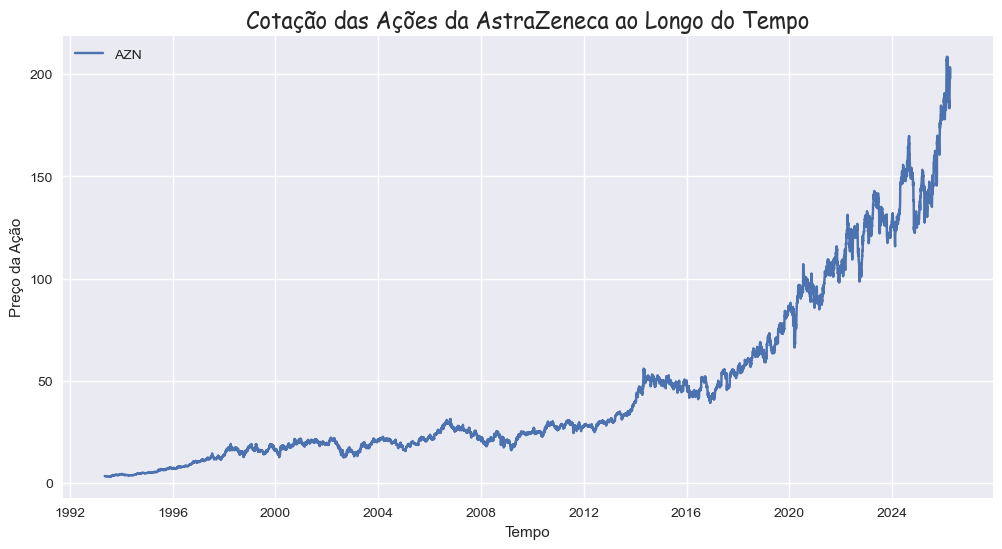

In [19]:
# Dataviz 12

# Dados
x = df['Date']
y = df['Close']

# Tamanho do gráfico (dpi especifica pixels por polegada)
plt.figure(figsize = (12,6), dpi = 100)

# Plot
plt.plot(x, y, label = 'AZN')

# Título
plt.title('Cotação das Ações da AstraZeneca ao Longo do Tempo', 
          fontdict = {'fontname': 'Comic Sans MS', 'fontsize': 16})

# Label
plt.xlabel('Tempo')
plt.ylabel('Preço da Ação')

# Inclui legenda
plt.legend()

# Salva a figura com alta resolução
plt.savefig('imagens/dataviz12.png', dpi = 300)

# Plot
plt.show()

# Fim